# 🎬 Movie Review Sentiment Analysis using Naive Bayes

**Author:** Divyanshjanu  
**Dataset:** [IMDB 50K Movie Reviews](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews)  
**Goal:** Predict whether a movie review is **Positive** or **Negative**

---

## Step 1: Import Libraries

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

## Step 2: Load the Dataset

Download the dataset from Kaggle:  
👉 https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews


In [18]:
df = pd.read_csv('IMDB Dataset.csv')

print(f'Dataset Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Dataset Shape: (50000, 2)
Columns: ['review', 'sentiment']


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [19]:
# Check for null values
print('Null values:')
print(df.isnull().sum())

print(f'\nTotal Reviews: {len(df)}')
print(f'\nSentiment Distribution:')
print(df['sentiment'].value_counts())

Null values:
review       0
sentiment    0
dtype: int64

Total Reviews: 50000

Sentiment Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


## Step 3: Exploratory Data Analysis (EDA)

Let's understand our data before building the model.

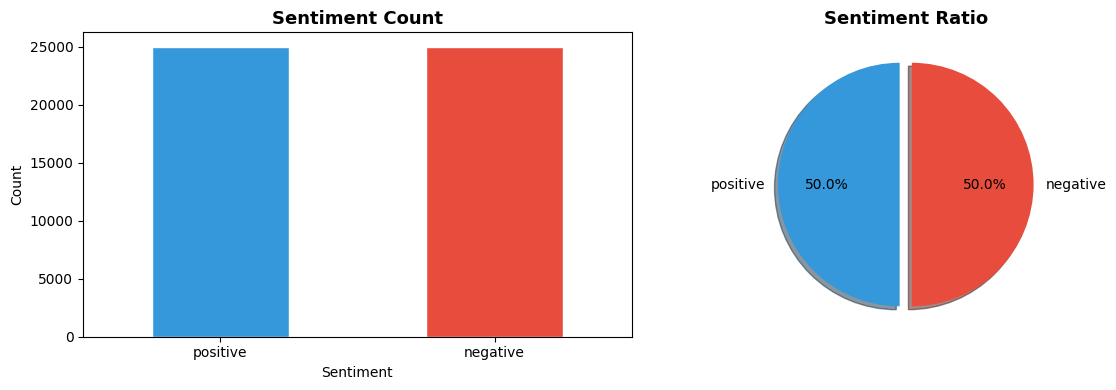

In [20]:
# Sentiment distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
colors = ['#3498db', '#e74c3c']
df['sentiment'].value_counts().plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Sentiment Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
df['sentiment'].value_counts().plot.pie(
    ax=axes[1], autopct='%1.1f%%', colors=colors,
    explode=(0.05, 0.05), shadow=True, startangle=90
)
axes[1].set_title('Sentiment Ratio', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

Average word count per sentiment:
sentiment
negative    229.5
positive    232.8
Name: word_count, dtype: float64


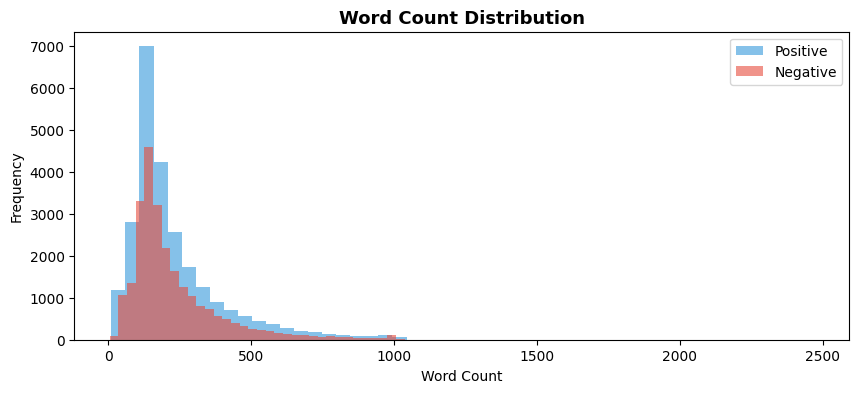

In [21]:
# Review length analysis
df['word_count'] = df['review'].apply(lambda x: len(x.split()))

print('Average word count per sentiment:')
print(df.groupby('sentiment')['word_count'].mean().round(1))

plt.figure(figsize=(10, 4))
plt.hist(df[df['sentiment']=='positive']['word_count'], bins=50, alpha=0.6, label='Positive', color='#3498db')
plt.hist(df[df['sentiment']=='negative']['word_count'], bins=50, alpha=0.6, label='Negative', color='#e74c3c')
plt.title('Word Count Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.legend()
plt.show()

## Step 4: Text Preprocessing

Before feeding text to our model, we need to clean it:

1. **Remove HTML tags** — IMDB reviews contain `<br/>` tags
2. **Remove special characters & numbers** — keep only letters
3. **Convert to lowercase** — "Good" and "good" should be the same

In [22]:
def clean_text(text):
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)

    # Keep only letters and spaces
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Convert to lowercase
    text = text.lower().strip()

    return text

df['clean_review'] = df['review'].apply(clean_text)

# Show before vs after
print('BEFORE:')
print(df['review'].iloc[0][:150])
print('\nAFTER:')
print(df['clean_review'].iloc[0][:150])

BEFORE:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with

AFTER:
one of the other reviewers has mentioned that after watching just  oz episode youll be hooked they are right as this is exactly what happened with me 


## Step 5: Convert Text to Numbers (Bag of Words)

Machine learning models need **numbers**, not text.  
We use **Bag of Words (CountVectorizer)** — it simply counts how many times each word appears in a review.

Example:
```
Review 1: "good movie"        →  [1, 1, 0]
Review 2: "bad movie bad"     →  [0, 1, 2]
                                  good  movie  bad
```

In [7]:
# Convert text to numbers using Bag of Words
vectorizer = CountVectorizer(max_features=5000, stop_words='english')

X = vectorizer.fit_transform(df['clean_review'])
y = df['sentiment'].map({'positive': 1, 'negative': 0})  # positive=1, negative=0

print(f'Feature Matrix Shape: {X.shape}')
print(f'→ {X.shape[0]} reviews, {X.shape[1]} unique words as features')

# Show some feature names
feature_names = vectorizer.get_feature_names_out()
print(f'\nSample words used as features: {list(feature_names[:20])}')

Feature Matrix Shape: (50000, 5000)
→ 50000 reviews, 5000 unique words as features

Sample words used as features: ['aaron', 'abandoned', 'abc', 'abilities', 'ability', 'able', 'absence', 'absent', 'absolute', 'absolutely', 'absurd', 'abuse', 'abused', 'abusive', 'abysmal', 'academy', 'accent', 'accents', 'accept', 'acceptable']


## Step 6: Split Data into Train & Test Sets

We split 80% for training and 20% for testing.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set: {X_train.shape[0]} reviews')
print(f'Testing set:  {X_test.shape[0]} reviews')

Training set: 40000 reviews
Testing set:  10000 reviews


## Step 7: Train the Naive Bayes Model

We use **Multinomial Naive Bayes** — it's designed for text classification with word counts.

The `alpha=1.0` parameter is called **Laplace Smoothing**. It prevents the model from assigning zero probability to words it hasn't seen during training.

In [9]:
model = MultinomialNB(alpha=1.0)
model.fit(X_train, y_train)

MultinomialNB()

## Step 8: Evaluate the Model

In [10]:
# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 84.58%


In [11]:
# Classification Report
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Classification Report:
              precision    recall  f1-score   support

    Negative       0.84      0.85      0.85      4961
    Positive       0.85      0.84      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



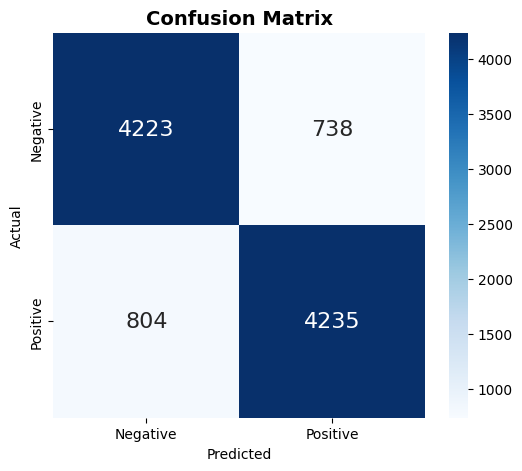

In [12]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'],
    annot_kws={'size': 16}
)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Step 9: Top Words for Each Sentiment

Let's see which words the model considers most indicative of positive and negative reviews.

In [13]:
# Get log probabilities for each class
neg_probs = model.feature_log_prob_[0]  # negative class
pos_probs = model.feature_log_prob_[1]  # positive class

# Difference: positive - negative
# High value = strong positive indicator
# Low value = strong negative indicator
diff = pos_probs - neg_probs

# Top 15 positive words
top_pos_idx = np.argsort(diff)[-15:]
top_pos = [(feature_names[i], diff[i]) for i in top_pos_idx]

# Top 15 negative words
top_neg_idx = np.argsort(diff)[:15]
top_neg = [(feature_names[i], diff[i]) for i in top_neg_idx]

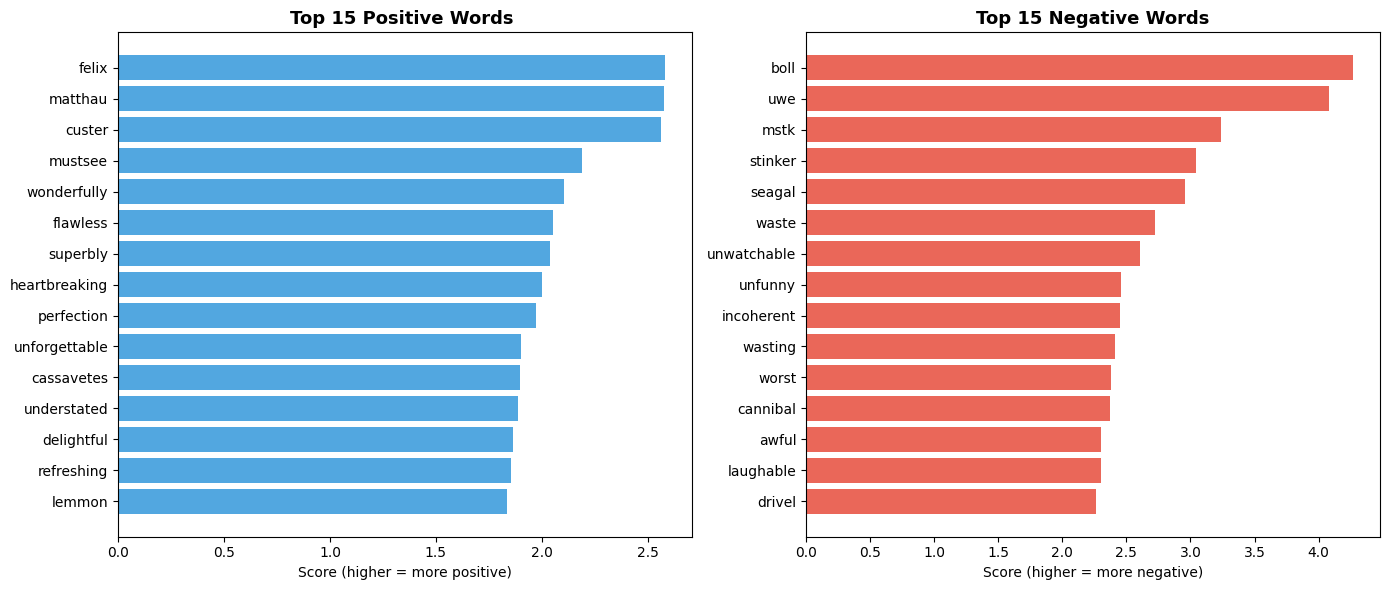

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Positive words
pos_df = pd.DataFrame(top_pos, columns=['Word', 'Score']).sort_values('Score')
axes[0].barh(pos_df['Word'], pos_df['Score'], color='#3498db', alpha=0.85)
axes[0].set_title('Top 15 Positive Words ', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Score (higher = more positive)')

# Negative words
neg_df = pd.DataFrame(top_neg, columns=['Word', 'Score']).sort_values('Score', ascending=False)
axes[1].barh(neg_df['Word'], neg_df['Score'].abs(), color='#e74c3c', alpha=0.85)
axes[1].set_title('Top 15 Negative Words', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Score (higher = more negative)')

plt.tight_layout()
plt.show()

## Step 10: Test with Custom Reviews

Let's see how our model performs on reviews we write ourselves!

In [15]:
def predict_sentiment(review):
    """Predict sentiment of a movie review"""
    cleaned = clean_text(review)
    vectorized = vectorizer.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    probability = model.predict_proba(vectorized)[0]

    label = ' Positive' if prediction == 1 else 'Negative'
    confidence = max(probability) * 100

    print(f'Review:     "{review[:80]}..."' if len(review) > 80 else f'Review:     "{review}"')
    print(f'Prediction: {label} ({confidence:.1f}% confident)')
    print()

In [16]:
test_reviews = [
    "This movie was absolutely amazing! Great acting and wonderful story.",
    "Terrible film. Waste of time. The plot was boring and made no sense.",
    "It was okay, nothing special but not bad either.",
    "One of the best movies I have ever seen! A true masterpiece.",
    "The worst movie of the year. Bad acting and horrible script.",
    "A fun movie with good humor. The whole family enjoyed it.",
]

for review in test_reviews:
    predict_sentiment(review)

Review:     "This movie was absolutely amazing! Great acting and wonderful story."
Prediction:  Positive (95.0% confident)

Review:     "Terrible film. Waste of time. The plot was boring and made no sense."
Prediction: Negative (99.9% confident)

Review:     "It was okay, nothing special but not bad either."
Prediction: Negative (91.6% confident)

Review:     "One of the best movies I have ever seen! A true masterpiece."
Prediction:  Positive (88.6% confident)

Review:     "The worst movie of the year. Bad acting and horrible script."
Prediction: Negative (99.9% confident)

Review:     "A fun movie with good humor. The whole family enjoyed it."
Prediction:  Positive (86.4% confident)



## 📝 Key Takeaways

1. **Naive Bayes** uses Bayes' Theorem to calculate probabilities and classify text
2. **Bag of Words** converts text into numbers by counting word frequencies
3. The model achieved **~85 accuracy** which is good for such a simple approach
4. Words like *"great"*, *"excellent"*, *"best"* strongly indicate positive reviews
5. Words like *"worst"*, *"awful"*, *"terrible"* strongly indicate negative reviews
6. Despite the "naive" independence assumption, it performs well on text data
